### Heart Failure Prediction Dataset

#### This dataset contains 11 features that can be used to predict possible heart disease.

#### I will implement Tree Ensemble models (Random Forest and XGBoost models)

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import os       

In [2]:
file_path = str(r"c:\Users\Admin\ML-concepts\datasets\heart.csv")
df = pd.read_csv(file_path)

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Attribute Information

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal]


### Target: HeartDisease -> Binary classification 

- 0 no disease

- 1 disease



### **EDA**

In [4]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
y.value_counts()

# balanced 

total = y.value_counts().sum()

df_y = pd.DataFrame(y.value_counts())
df_y['percentage'] = df_y['count'].apply(lambda row: row/total).round(2)
df_y # equal class

,count,percentage
HeartDisease,,
1,508,0.55
0,410,0.45


In [5]:
df.select_dtypes(include='number')

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [6]:
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [7]:

categorical =  df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [8]:
for col in categorical.columns:
    print(categorical[col].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [9]:
# RestingECG - Ordinal encoder
# else; One hot encoder

<Axes: >

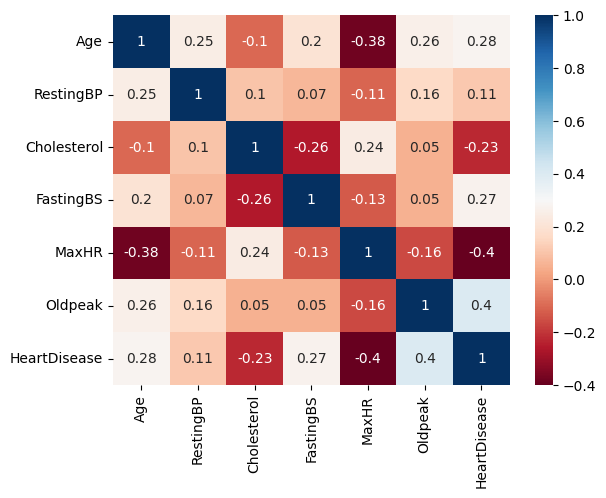

In [10]:
numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr().round(2),cmap='RdBu',annot=True)

### Correlation map shows feature vs feature matrix and interaction between variables. Correlation is normalized Covariance, and it explains feature direction, if correlation is positive, that means increasing one feature leads to increasing of another

- How two variables move together


#### We can observe that MaxHR has a negative correlation with HeartDisease

In [11]:
df = df.drop(columns={'MaxHR'})

In [12]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,N,0.0,Up,0


In [13]:
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


### One hot encoder: -> Transforms categorical variables with 3>= values into numerical columns such as:

var x = [ low, medium , none] = [0,0,1]

In [14]:
valid = []
for col in categorical.columns:
    print(categorical[col].value_counts())
    valid.append(col)

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [15]:
df = pd.get_dummies(data=df,prefix=valid,columns=valid,dtype=int)

In [16]:
df

,Age,RestingBP,Cholesterol,FastingBS,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,0.0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,1.0,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,0.0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,1.5,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,0.0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,1.2,1,0,1,0,0,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,3.4,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,1.2,1,0,1,1,0,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,0.0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0


In [ ]:
X = [col for col in df.columns if col != 'HeartDisease']
X = df.loc[:,X]
y = df.loc[:,'HeartDisease']


0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=41)

In [29]:
print(len(X_test))
print(len(X_train))
print(y_train.shape)

184
734
(734,)


In [37]:
### Scaling the data

scale_this = []
for col in df.select_dtypes(include='number'):
    if (df[col].max() - df[col].min()) > 10:
        scale_this.append(col)

In [40]:
from sklearn.compose import ColumnTransformer

In [41]:
ColumnTransformer?

Init signature:
ColumnTransformer(
    transformers,
    *,
    remainder='drop',
    sparse_threshold=0.3,
    n_jobs=None,
    transformer_weights=None,
    verbose=False,
    verbose_feature_names_out=True,
    force_int_remainder_cols='deprecated',
)
Docstring:     
Applies transformers to columns of an array or pandas DataFrame.

This estimator allows different columns or column subsets of the input
to be transformed separately and the features generated by each transformer
will be concatenated to form a single feature space.
This is useful for heterogeneous or columnar data, to combine several
feature extraction mechanisms or transformations into a single transformer.

Read more in the :ref:`User Guide <column_transformer>`.

.. versionadded:: 0.20

Parameters
----------
transformers : list of tuples
    List of (name, transformer, columns) tuples specifying the
    transformer objects to be applied to subsets of the data.

    name : str
        Like in Pipeline and FeatureUnion

In [43]:
from sklearn.preprocessing import StandardScaler

In [68]:
preprocessing = ColumnTransformer(transformers=[
    ('scaler',StandardScaler(),scale_this)
]
)

In [63]:
model = [DecisionTreeClassifier(),RandomForestClassifier(),XGBClassifier()]
hyperparams = [{'Tree':{'min_samples_split':[2,10, 30, 50, 100, 200, 300, 700],'max_depth_list':[1,2, 3, 4, 8, 16, 32, 64, None]}},{'RF':{'min_samples_list':[2,10, 30, 50, 100, 200, 300, 700],
'n_estimators':[10,50,100,500],'max_depth_list':[2,4,8,16,32,None]}}]


In [66]:
from sklearn.pipeline import Pipeline

In [70]:
pipe = Pipeline(steps=[
    preprocessing,
    model

])

In [71]:
pipe

ValueError: too many values to unpack (expected 2)

ValueError: too many values to unpack (expected 2)

Pipeline(steps=[ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                 ['Age', 'RestingBP',
                                                  'Cholesterol'])]),
                [DecisionTreeClassifier(), RandomForestClassifier(),
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=Fals...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat